In [1]:
import os
print(os.listdir('/kaggle/input/datasets/abdallahalidev/plantvillage-dataset'))

['segmented', 'grayscale', 'plantvillage dataset', 'color']


In [1]:
import os
base_path = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'
print(os.listdir(base_path))

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___Leaf_Mold', 'Tomato__

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

Converting y_train to on dimensional array to be inserted in the convolution neural layer

In [3]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1786285847.343310      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786285847.346285      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [4]:
class_names = train_ds.class_names
print(class_names)
print(f"Number of classes: {len(class_names)}")

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

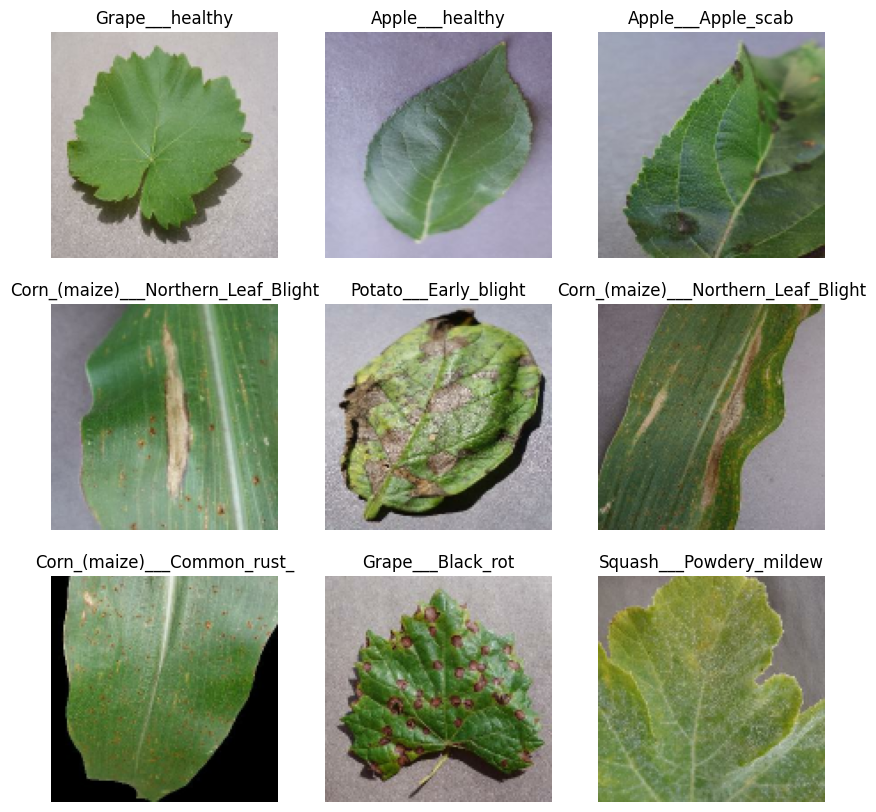

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [9]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [5]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(num_classes)

38


In [8]:
# The CNN
myCNN = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [9]:
myCNN.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
history = myCNN.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


2026-08-09 11:16:06.036381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 11:16:06.184947: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   7/1358 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.0192 - loss: 4.6884    

I0000 00:00:1786274167.770960     145 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1356/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4702 - loss: 2.0204

2026-08-09 11:17:09.795555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 11:17:09.942260: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 85s 59ms/step - accuracy: 0.6234 - loss: 1.3516 - val_accuracy: 0.7800 - val_loss: 0.7239
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8252 - loss: 0.5667 - val_accuracy: 0.8390 - val_loss: 0.5153
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8854 - loss: 0.3589 - val_accuracy: 0.8575 - val_loss: 0.4706
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.9222 - loss: 0.2425 - val_accuracy: 0.8656 - val_loss: 0.4730
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.9451 - loss: 0.1698 - val_accuracy: 0.8683 - val_loss: 0.5013


The result show that our model is overfitted. i.e. as val_loss is increasing despite high accuracy on the test _ set so we shall use techniques to improve it. here we may use data augmentation, dropout, batch normalization


# Data Augmentation

In [6]:

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)


# Applying Batch Normalization

In [7]:
myCNN_v2 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    data_augmentation,

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
myCNN_v2.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [10]:
history_v2 = myCNN_v2.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.5491 - loss: 1.5120 - val_accuracy: 0.7360 - val_loss: 0.8769
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.5879 - loss: 1.3618 - val_accuracy: 0.7721 - val_loss: 0.7556
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.6133 - loss: 1.2813 - val_accuracy: 0.8067 - val_loss: 0.6373
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.6306 - loss: 1.1999 - val_accuracy: 0.7858 - val_loss: 0.6966
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.6519 - loss: 1.1191 - val_accuracy: 0.8255 - val_loss: 0.5701
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.6697 - loss: 1.0654 - val_accuracy: 0.8385 - val_loss: 0.5278
Epoch 7/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.6800 - loss: 1.0243 - val_accuracy: 0.8267 - val_loss: 0.5582
Epoch 8/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.6909 -

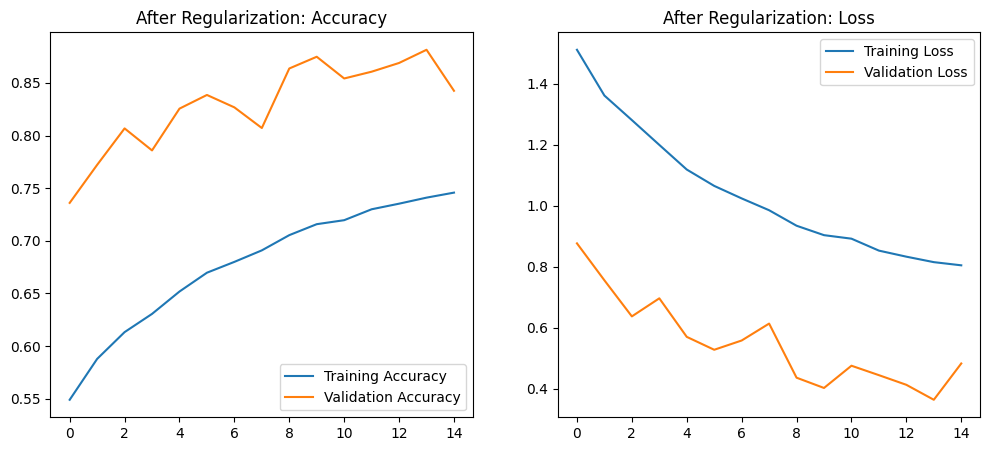

In [11]:
acc2 = history_v2.history['accuracy']
val_acc2 = history_v2.history['val_accuracy']
loss2 = history_v2.history['loss']
val_loss2 = history_v2.history['val_loss']
epochs_range2 = range(len(acc2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range2, acc2, label='Training Accuracy')
plt.plot(epochs_range2, val_acc2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('After Regularization: Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range2, loss2, label='Training Loss')
plt.plot(epochs_range2, val_loss2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('After Regularization: Loss')

plt.show()

In [12]:
myCNN_v3 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    data_augmentation,

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [13]:
myCNN_v3.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [14]:
history_v3 = myCNN_v3.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 108s 77ms/step - accuracy: 0.1277 - loss: 3.4898 - val_accuracy: 0.1363 - val_loss: 3.2427
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 41ms/step - accuracy: 0.1262 - loss: 3.2734 - val_accuracy: 0.1409 - val_loss: 3.2659
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 41ms/step - accuracy: 0.1316 - loss: 3.2288 - val_accuracy: 0.1413 - val_loss: 3.1740
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 56s 41ms/step - accuracy: 0.1314 - loss: 3.2314 - val_accuracy: 0.1400 - val_loss: 4.1474
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.1335 - loss: 3.2149 - val_accuracy: 0.1499 - val_loss: 3.1627
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.1311 - loss: 3.2188 - val_accuracy: 0.1470 - val_loss: 3.1491
Epoch 7/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.1330 - loss: 3.2200 - val_accuracy: 0.1504 - val_loss: 3.1586
Epoch 8/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.1344 

KeyboardInterrupt: 

Finalizing version 2 after letting it go through more epochs

In [15]:
history_v2 = myCNN_v2.fit(train_ds, validation_data=val_ds, epochs=25)

Epoch 1/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - accuracy: 0.7548 - loss: 0.7832 - val_accuracy: 0.8704 - val_loss: 0.4059
Epoch 2/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - accuracy: 0.7593 - loss: 0.7550 - val_accuracy: 0.8705 - val_loss: 0.4000
Epoch 3/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.7633 - loss: 0.7431 - val_accuracy: 0.8848 - val_loss: 0.3784
Epoch 4/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.7681 - loss: 0.7211 - val_accuracy: 0.8607 - val_loss: 0.4383
Epoch 5/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.7719 - loss: 0.7103 - val_accuracy: 0.8769 - val_loss: 0.4048
Epoch 6/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.7721 - loss: 0.7135 - val_accuracy: 0.8860 - val_loss: 0.3618
Epoch 7/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 46s 34ms/step - accuracy: 0.7756 - loss: 0.6989 - val_accuracy: 0.9061 - val_loss: 0.3060
Epoch 8/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 47s 35ms/step - accuracy: 0.7820 -

# Saving the traned model

In [16]:
myCNN_v2.save('/kaggle/working/leaf_disease_cnn_v2.keras')

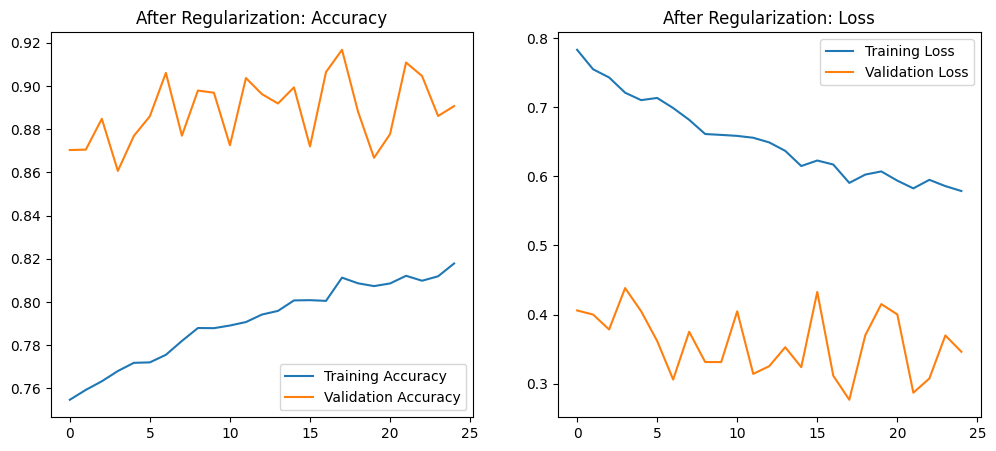

In [17]:
acc2 = history_v2.history['accuracy']
val_acc2 = history_v2.history['val_accuracy']
loss2 = history_v2.history['loss']
val_loss2 = history_v2.history['val_loss']
epochs_range2 = range(len(acc2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range2, acc2, label='Training Accuracy')
plt.plot(epochs_range2, val_acc2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('After Regularization: Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range2, loss2, label='Training Loss')
plt.plot(epochs_range2, val_loss2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('After Regularization: Loss')

plt.show()